In [1]:
import pandas as pd, numpy as np, os, glob, re

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
plt.rcParams['figure.dpi'] = 200

In [4]:
from pyfonts import load_google_font, set_default_font

font = load_google_font("IBM Plex Sans", weight='regular', italic=False)
bold_font = load_google_font("IBM Plex Sans", weight='bold', italic=False)

set_default_font(font)

In [ ]:
df = pd.read_csv('data/Survey_Data_R.csv')

In [7]:
df_copy = df.copy()

In [8]:
df_copy

,Timestamp,Column 1,Age,Gender,Educational attainment,Employment,Income level (monthly),Do you have a bank account?,​​Does your bank offer facilities on mobile banking?​,Do you use mobile banking?,...,​​I receive useful updates and notifications regarding my account.​,​​I can use the mobile banking app reliably even in areas with slow internet connectivity.​,​​The app’s features save me time compared to in-person banking services.​,​​The mobile banking app provides prompt notifications regarding my transactions.​,"​​The app offers multiple support channels (e.g., chat, email, phone) to resolve issues.​",​​Customer support through the app responds promptly and​ resolves concerns effectively.,​​I find the support staff to be knowledgeable and helpful in resolving issues.​,​​The mobile banking app provides timely responses to my queries and concerns.​,​​I feel supported by the app’s customer service when I experience issues.​,​​The app allows me to easily track the status of my support requests.​
0,1/24/2025 8:58:01,I acknowledge.,26-30,Female,Bachelors,Employed,"P24,001 to P48,000",Yes,Yes,Yes,...,4 - Agree,3 - Neither agree nor disagree,4 - Agree,4 - Agree,3 - Neither agree nor disagree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,4 - Agree
1,1/24/2025 9:15:39,I acknowledge.,26-30,Female,Bachelors,Employed,"P24,001 to P48,000",Yes,Yes,Yes,...,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree
2,1/18/2025 5:31:19,I acknowledge.,26-30,Female,Bachelors,Employed,"P24,001 to P48,000",Yes,Yes,Yes,...,5 - Strongly agree,3 - Neither agree nor disagree,5 - Strongly agree,5 - Strongly agree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,4 - Agree
3,1/24/2025 8:58:01,I acknowledge.,26-30,Female,Bachelors,Employed,"P24,001 to P48,000",Yes,Yes,Yes,...,4 - Agree,3 - Neither agree nor disagree,4 - Agree,4 - Agree,3 - Neither agree nor disagree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,4 - Agree
4,1/24/2025 8:58:01,I acknowledge.,26-30,Female,Bachelors,Employed,"P24,001 to P48,000",Yes,Yes,Yes,...,4 - Agree,3 - Neither agree nor disagree,4 - Agree,4 - Agree,3 - Neither agree nor disagree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,4 - Agree
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,1/18/2025 13:42:53,I acknowledge.,26-30,Female,Undergraduate,Employed,"P24,001 to P48,000",Yes,Yes,Yes,...,5 - Strongly agree,3 - Neither agree nor disagree,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree,3 - Neither agree nor disagree,3 - Neither agree nor disagree,5 - Strongly agree,3 - Neither agree nor disagree,5 - Strongly agree
398,10/4/2025 15:54:57,I acknowledge.,21-25,Male,Masters/Graduate,Employed,"P24,001 to P48,000",Yes,Yes,Yes,...,4 - Agree,2 - Disagree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,3 - Neither agree nor disagree,3 - Neither agree nor disagree,4 - Agree
399,10/4/2025 15:54:57,I acknowledge.,21-25,Male,Masters/Graduate,Employed,"P24,001 to P48,000",Yes,Yes,Yes,...,4 - Agree,2 - Disagree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,3 - Neither agree nor disagree,3 - Neither agree nor disagree,4 - Agree
400,10/4/2025 15:54:57,I acknowledge.,21-25,Male,Masters/Graduate,Employed,"P24,001 to P48,000",Yes,Yes,Yes,...,4 - Agree,2 - Disagree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,3 - Neither agree nor disagree,3 - Neither agree nor disagree,4 - Agree


In [9]:
# Examine the structure of the survey data
print("📊 SURVEY DATA OVERVIEW")
print("=" * 50)
print(f"Dataset shape: {df_copy.shape}")
print(f"\nColumn names:")
for i, col in enumerate(df_copy.columns):
    print(f"   {i+1}. {col}")

print(f"\n📋 First few rows preview:")
print(df_copy.head(3))

📊 SURVEY DATA OVERVIEW
Dataset shape: (402, 41)

Column names:
   1. Timestamp
   2. Column 1
   3. Age
   4. Gender
   5. Educational attainment
   6. Employment
   7. Income level (monthly)
   8. Do you have a bank account?
   9. ​​Does your bank offer facilities on mobile banking?​ 
   10. Do you use mobile banking?
   11. Frequency of using mobile banking
   12. How long have you been using mobile banking services?
   13. Which bank do you use most frequently for mobile banking transactions?
   14. ​​The mobile banking app allows me to easily access and manage my​ account at any time. 
   15. ​​The mobile banking app works efficiently across multiple devices (e.g., smartphone,​ ​tablet).​ 
   16. ​​The loading speed of the mobile banking app is fast and reliable.​
   17. ​​The mobile banking app’s interface is user-friendly and intuitive to navigate​. 
   18. ​​I can easily access essential services, such as transfers and bill payments, within the​ app. 
   19. ​​The app has minima

In [10]:
# Check column names to identify demographic variables
print("📋 COLUMN NAMES:")
columns = df_copy.columns.tolist()
for i, col in enumerate(columns):
    print(f"{i+1:2d}. {col}")
    
print(f"\nTotal columns: {len(columns)}")

# Look for demographic-related columns
demographic_keywords = ['age', 'gender', 'education', 'employment', 'income', 'level', 'attainment']
print(f"\n🔍 POTENTIAL DEMOGRAPHIC COLUMNS:")
for col in columns:
    if any(keyword.lower() in col.lower() for keyword in demographic_keywords):
        print(f"   • {col}")

📋 COLUMN NAMES:
 1. Timestamp
 2. Column 1
 3. Age
 4. Gender
 5. Educational attainment
 6. Employment
 7. Income level (monthly)
 8. Do you have a bank account?
 9. ​​Does your bank offer facilities on mobile banking?​ 
10. Do you use mobile banking?
11. Frequency of using mobile banking
12. How long have you been using mobile banking services?
13. Which bank do you use most frequently for mobile banking transactions?
14. ​​The mobile banking app allows me to easily access and manage my​ account at any time. 
15. ​​The mobile banking app works efficiently across multiple devices (e.g., smartphone,​ ​tablet).​ 
16. ​​The loading speed of the mobile banking app is fast and reliable.​
17. ​​The mobile banking app’s interface is user-friendly and intuitive to navigate​. 
18. ​​I can easily access essential services, such as transfers and bill payments, within the​ app. 
19. ​​The app has minimal errors and disruptions when I perform banking tasks.​ 
20. ​​The design of the mobile banking

🎯 CREATING PIE CHARTS WITH LEGENDS (ZERO OVERLAP)
✅ Age: 5 categories with legend
✅ Gender: 4 categories with legend
✅ Educational attainment: 6 categories with legend
✅ Employment: 4 categories with legend
✅ Income level (monthly): 6 categories with legend


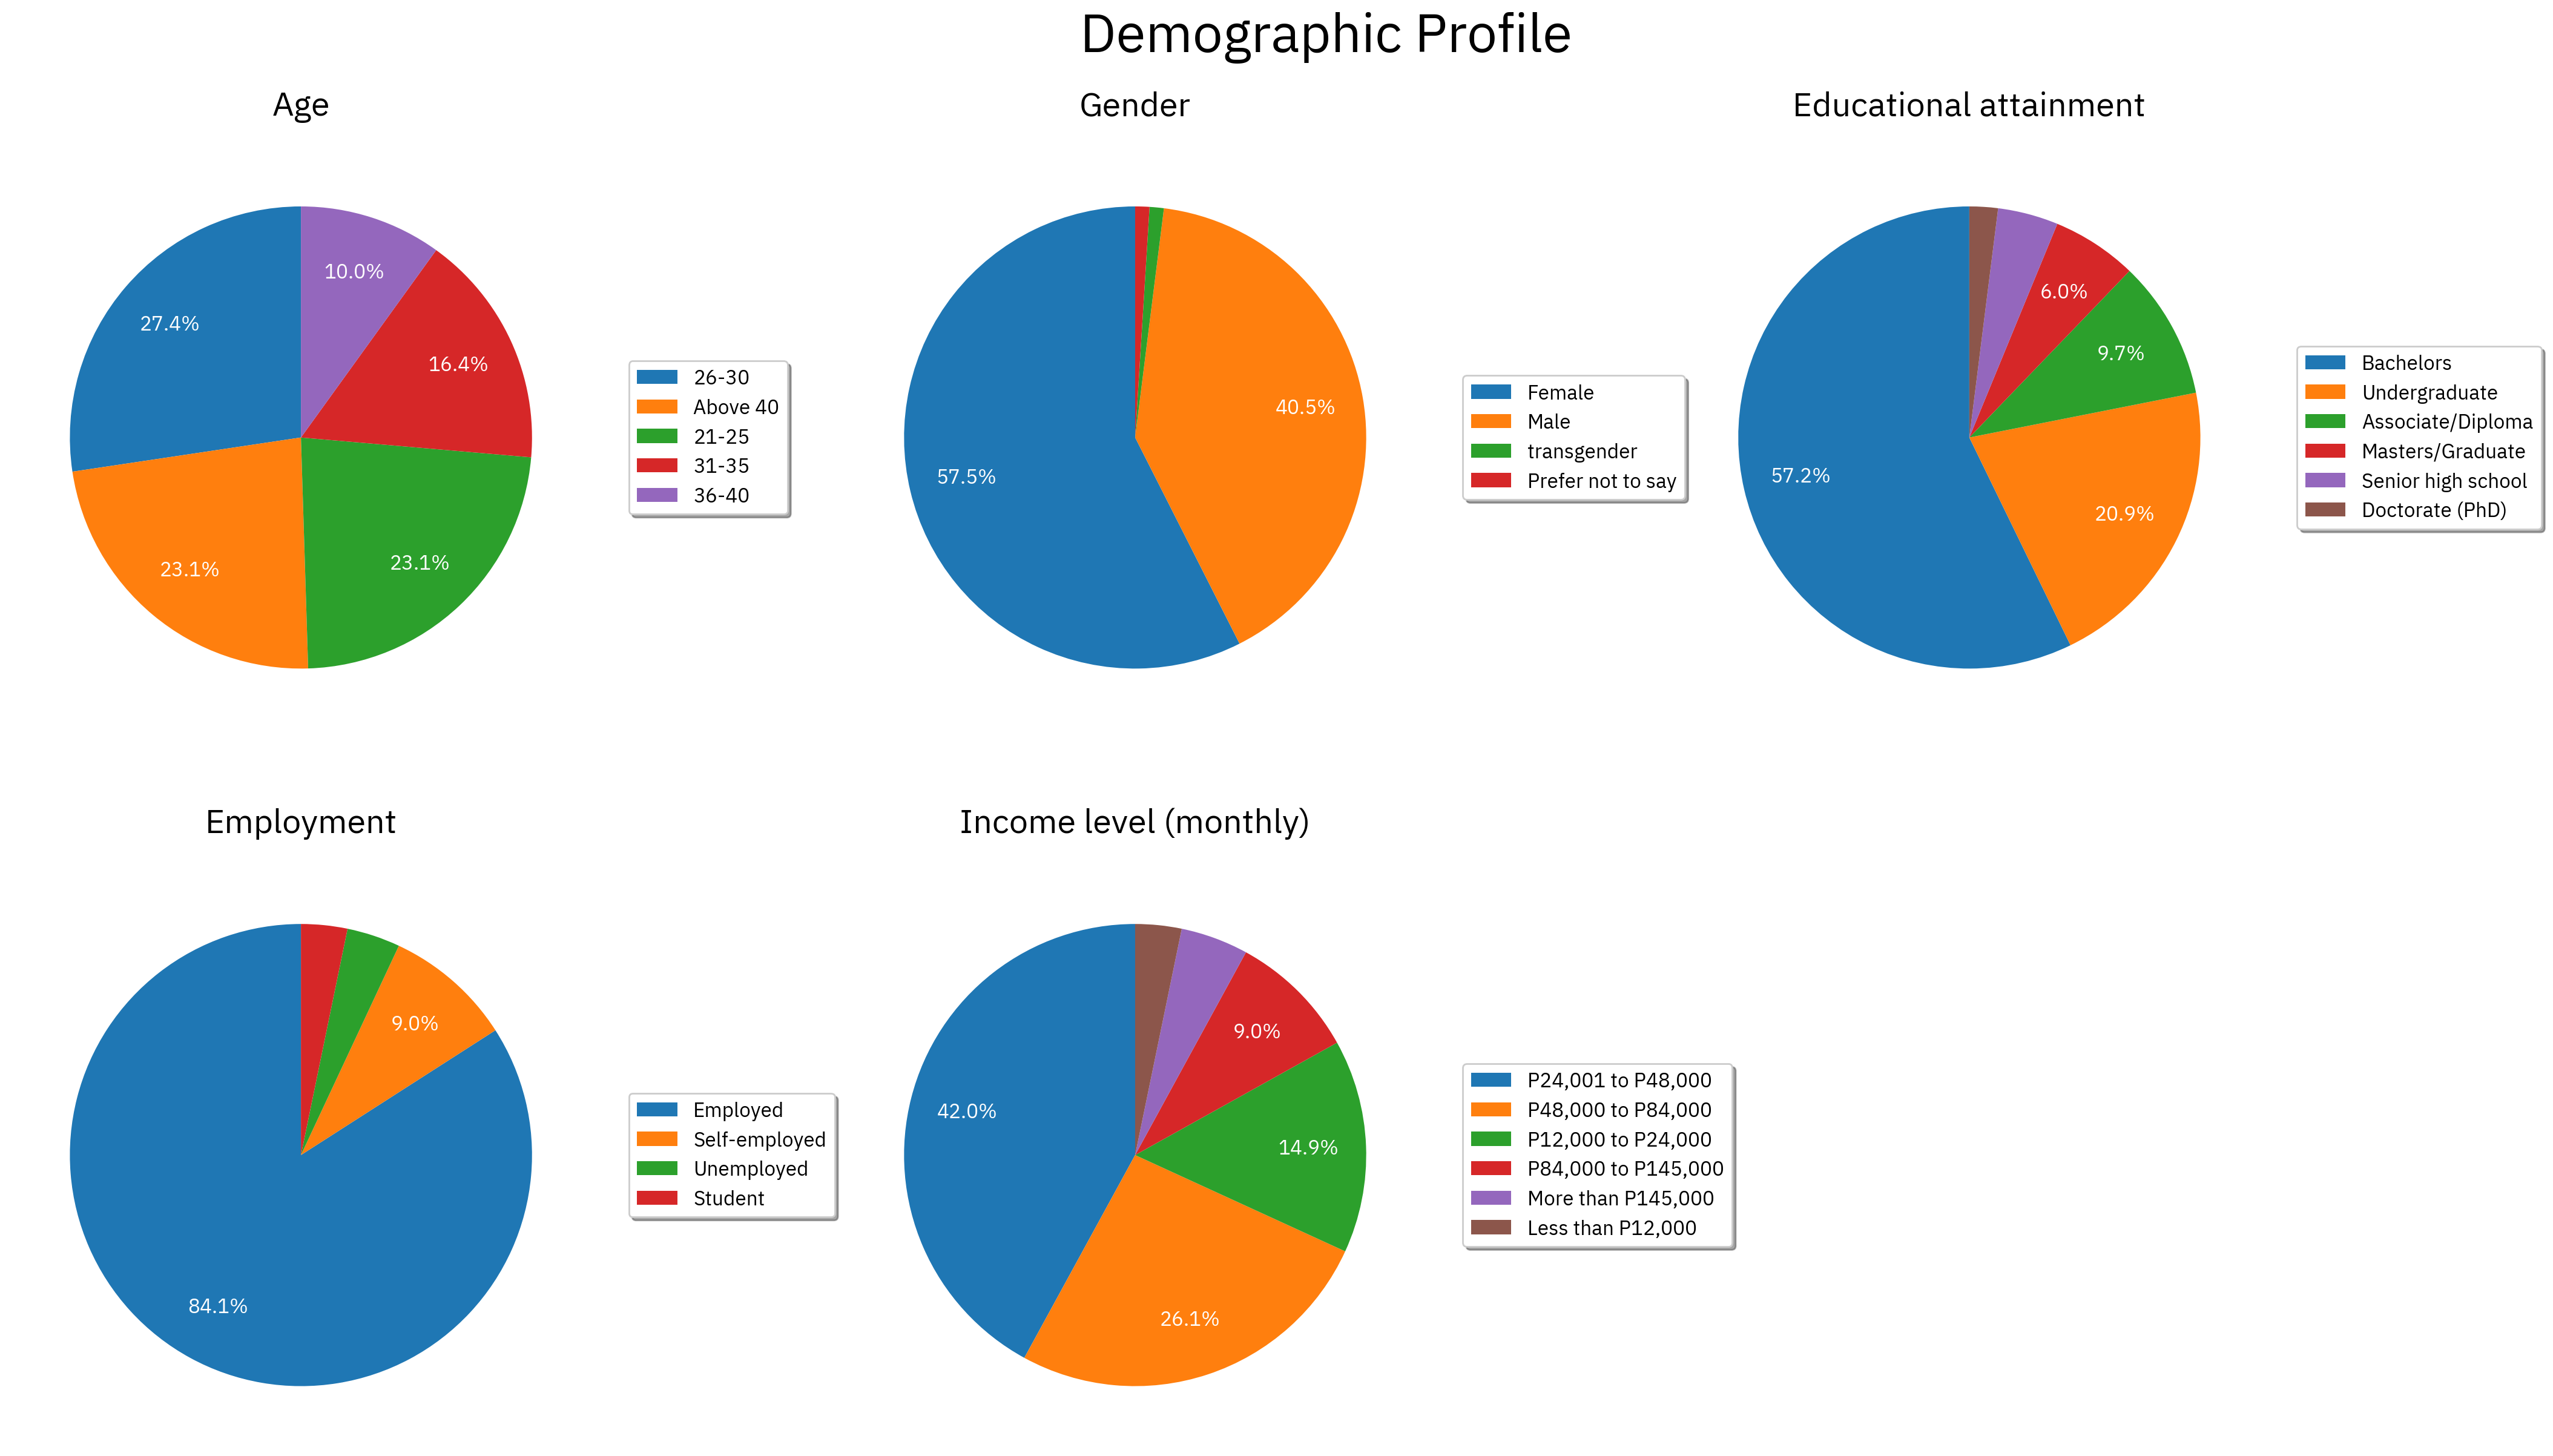


🎨 LEGEND-BASED SOLUTION BENEFITS:
   ✅ Zero label overlap - completely eliminated
   ✅ Percentages only shown for slices > 5%
   ✅ Complete information in legend (counts + percentages)
   ✅ Cleaner, professional appearance
   ✅ Better readability for all categories


In [11]:
# Set up the plotting style with IBM Plex Sans font
plt.rcParams['font.family'] = 'IBM Plex Sans'
plt.rcParams['font.size'] = 10

# Set color palette with more distinct colors
colors = plt.cm.tab10(np.linspace(0, 1, 10))

demographic_columns = {
    'Age': 'Age',
    'Gender': 'Gender', 
    'Educational attainment': 'Educational attainment',
    'Employment': 'Employment',
    'Income level (monthly)': 'Income level (monthly)'
}

print("🎯 CREATING PIE CHARTS WITH LEGENDS (ZERO OVERLAP)")
print("=" * 55)

# Create subplots with more space for legends
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

# Create pie charts for each demographic variable
for i, (display_name, column_name) in enumerate(demographic_columns.items()):
    ax = axes[i]
    
    # Get value counts for the column
    value_counts = df_copy[column_name].value_counts()
    
    # Create pie chart WITHOUT labels on the pie itself
    wedges, texts, autotexts = ax.pie(value_counts.values, 
                                     labels=None,  # No direct labels
                                     autopct=lambda pct: f'{pct:.1f}%' if pct > 5 else '',  # Only show % for slices > 5%
                                     startangle=90,
                                     colors=colors[:len(value_counts)],
                                     pctdistance=0.75,  # Move percentages closer to edge
                                     textprops={'fontsize': 12, 'fontweight': 'bold'})
    
    # Set title
    ax.set_title(f'{display_name}', 
                fontsize=20, fontweight='bold', pad=20)
    
    # Make percentage text white and bold
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(12)
    
    # Create legend outside the pie chart with percentages and counts
    legend_labels = [f'{label}' 
                    for label, count in value_counts.items()]
    ax.legend(wedges, legend_labels, 
             loc='center left', 
             bbox_to_anchor=(1.05, 0.5),
             fontsize=12,
             frameon=True,
             fancybox=True,
             shadow=True)
    
    print(f"✅ {display_name}: {len(value_counts)} categories with legend")

# Remove the last empty subplot
axes[5].remove()

# Adjust layout to accommodate legends
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Make room for legends
plt.suptitle('Demographic Profile', 
             fontsize=32, fontweight='bold', y=1.02)

plt.show()

print(f"\n🎨 LEGEND-BASED SOLUTION BENEFITS:")
print("   ✅ Zero label overlap - completely eliminated")
print("   ✅ Percentages only shown for slices > 5%")
print("   ✅ Complete information in legend (counts + percentages)")
print("   ✅ Cleaner, professional appearance")
print("   ✅ Better readability for all categories")


🎯 CREATING PIE CHARTS WITH LEGENDS (ZERO OVERLAP)
✅ Frequency of using mobile banking: 4 categories with legend
✅ How long have you been using mobile banking services?: 4 categories with legend


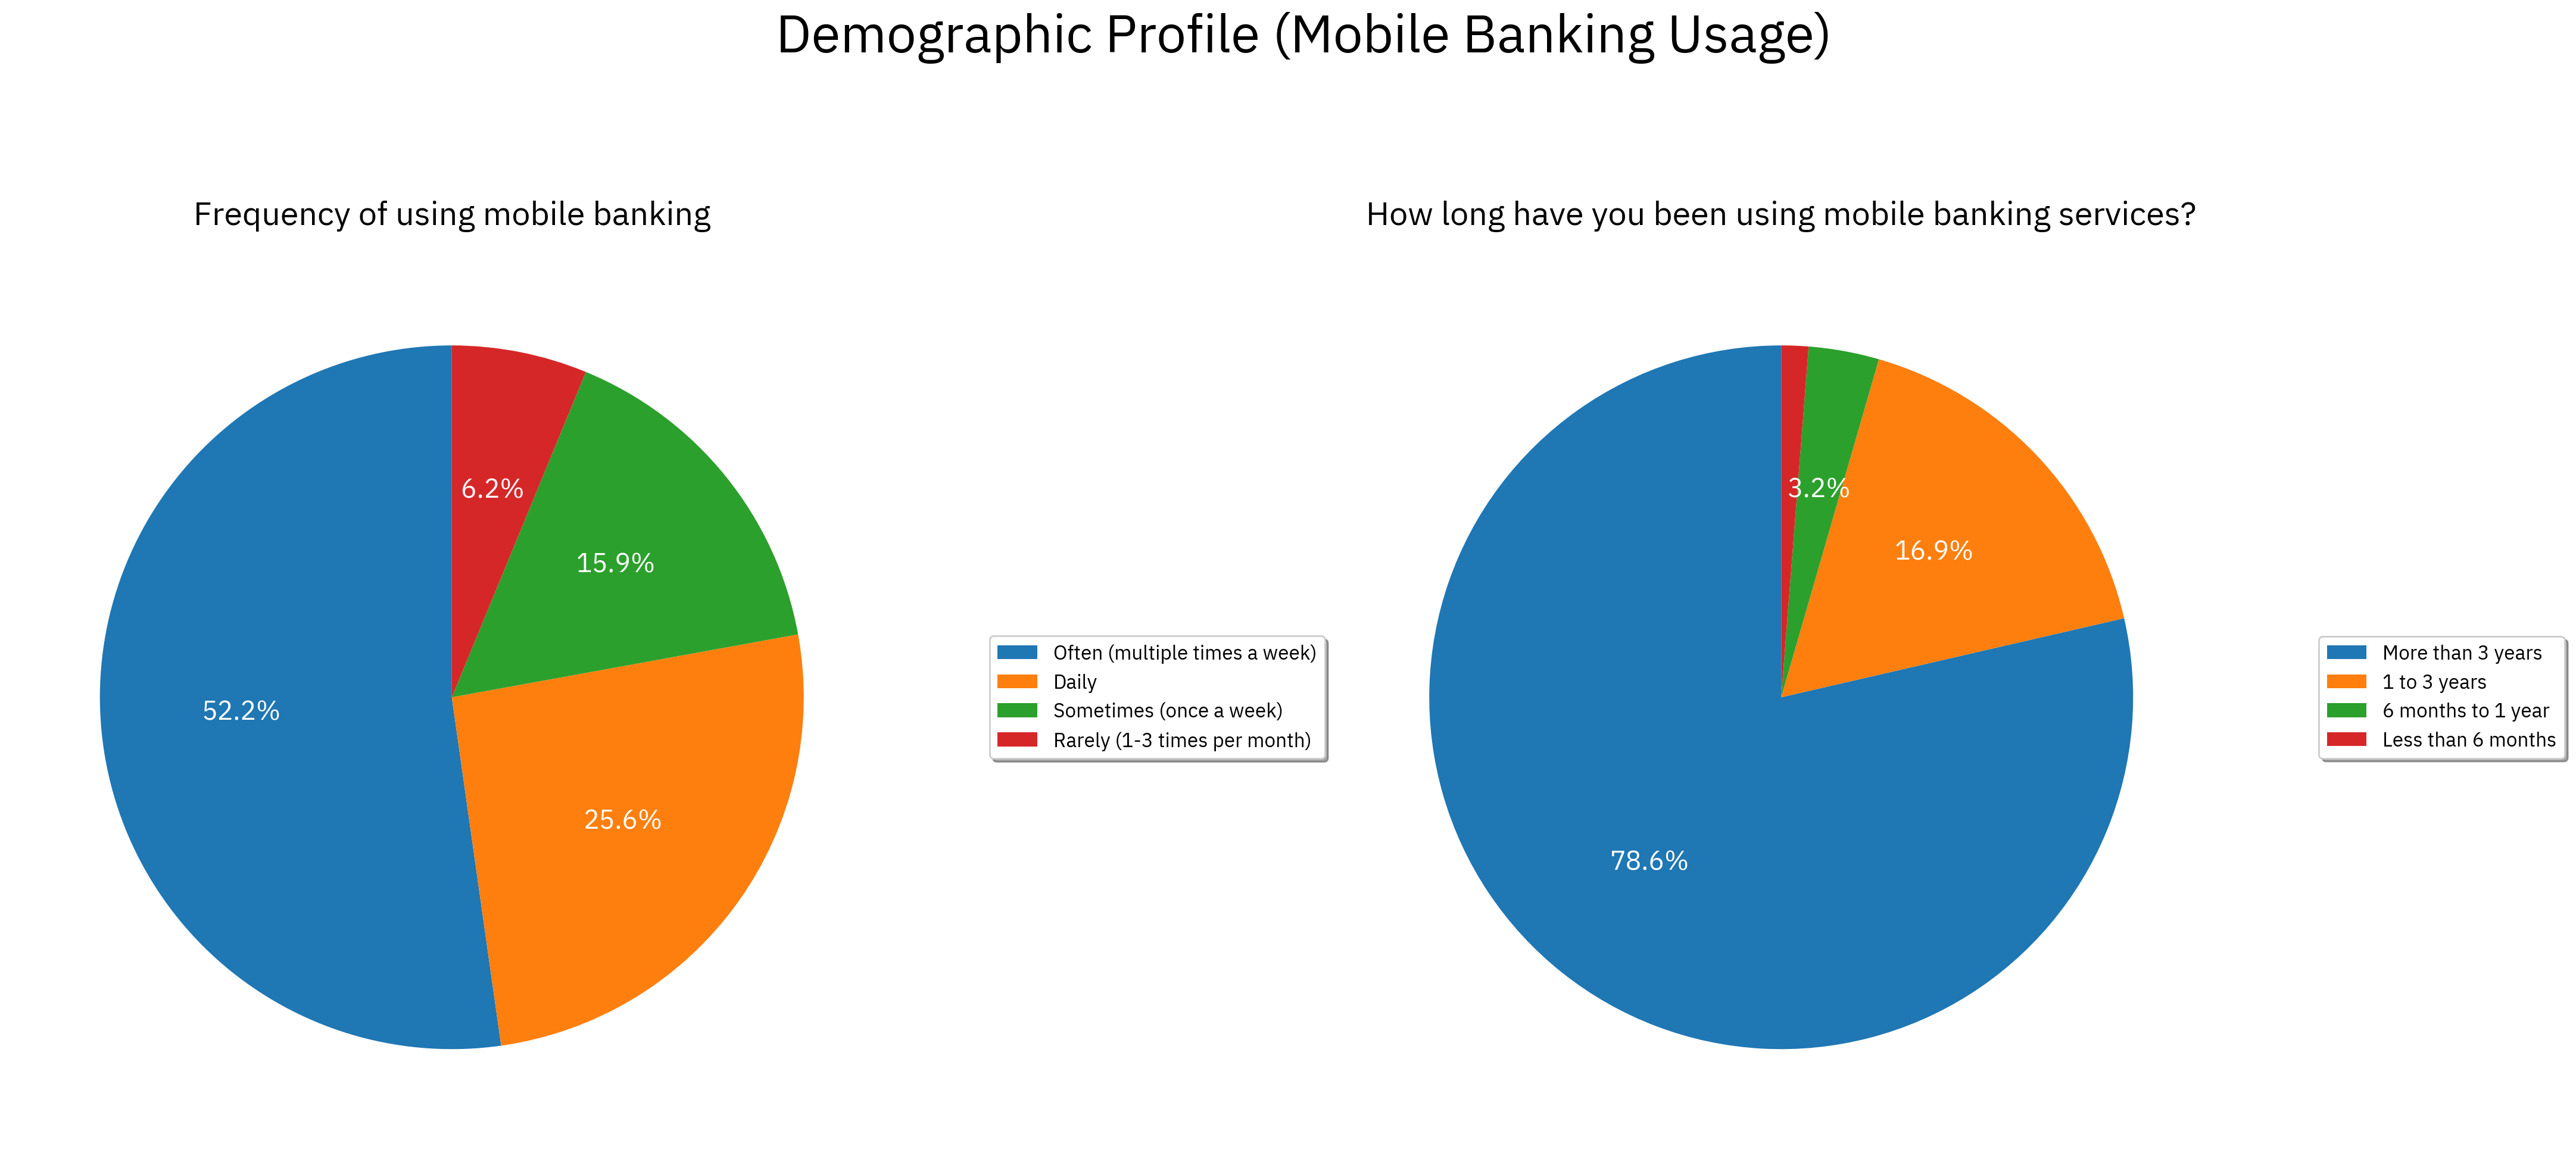


🎨 LEGEND-BASED SOLUTION BENEFITS:
   ✅ Zero label overlap - completely eliminated
   ✅ More detailed information (shows counts + percentages)
   ✅ Cleaner, professional appearance
   ✅ Better readability for all categories
   ✅ Easier to match colors with categories


In [12]:
# ALTERNATIVE SOLUTION: PIE CHARTS WITH LEGENDS (CLEANEST APPROACH)
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting style with IBM Plex Sans font
plt.rcParams['font.family'] = 'IBM Plex Sans'
plt.rcParams['font.size'] = 10

# Set color palette with more distinct colors
colors = plt.cm.tab10(np.linspace(0, 1, 10))

demographic_columns = {
    'Frequency of using mobile banking': 'Frequency of using mobile banking',
    'How long have you been using mobile banking services?': 'How long have you been using mobile banking services?'
}

print("🎯 CREATING PIE CHARTS WITH LEGENDS (ZERO OVERLAP)")
print("=" * 55)

# Create subplots with more space for legends
fig, axes = plt.subplots(1, 2, figsize=(22, 12))
axes = axes.flatten()

# Create pie charts for each demographic variable
for i, (display_name, column_name) in enumerate(demographic_columns.items()):
    ax = axes[i]
    
    # Get value counts for the column
    value_counts = df_copy[column_name].value_counts()
    
    # Create pie chart WITHOUT labels on the pie itself
    wedges, texts, autotexts = ax.pie(value_counts.values, 
                                     labels=None,  # No direct labels
                                     autopct=lambda pct: f'{pct:.1f}%' if pct > 2.5 else '',  # Only show % for slices > 5%
                                     startangle=90,
                                     colors=colors[:len(value_counts)],
                                     pctdistance=0.6,  # Move percentages closer to edge
                                     textprops={'fontsize': 14, 'fontweight': 'bold'})
    
    # Set title
    ax.set_title(f'{display_name}', 
                fontsize=20, fontweight='bold', pad=20)
    
    # Make percentage text white and bold
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(16)
        
    # Create legend outside the pie chart
    legend_labels = [f'{label}' for label, count in value_counts.items()]
    ax.legend(wedges, legend_labels, 
             loc='center left', 
             bbox_to_anchor=(1.1, 0.5),
             fontsize=12,
             frameon=True,
             fancybox=True,
             shadow=True)
    
    print(f"✅ {display_name}: {len(value_counts)} categories with legend")

# Remove the last empty subplot

# Adjust layout to accommodate legends
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Make room for legends
plt.suptitle('Demographic Profile (Mobile Banking Usage)', 
             fontsize=32, fontweight='bold', y=0.98)

plt.show()

print(f"\n🎨 LEGEND-BASED SOLUTION BENEFITS:")
print("   ✅ Zero label overlap - completely eliminated")
print("   ✅ More detailed information (shows counts + percentages)")
print("   ✅ Cleaner, professional appearance")
print("   ✅ Better readability for all categories")
print("   ✅ Easier to match colors with categories")

In [13]:
df_copy

,Timestamp,Column 1,Age,Gender,Educational attainment,Employment,Income level (monthly),Do you have a bank account?,​​Does your bank offer facilities on mobile banking?​,Do you use mobile banking?,...,​​I receive useful updates and notifications regarding my account.​,​​I can use the mobile banking app reliably even in areas with slow internet connectivity.​,​​The app’s features save me time compared to in-person banking services.​,​​The mobile banking app provides prompt notifications regarding my transactions.​,"​​The app offers multiple support channels (e.g., chat, email, phone) to resolve issues.​",​​Customer support through the app responds promptly and​ resolves concerns effectively.,​​I find the support staff to be knowledgeable and helpful in resolving issues.​,​​The mobile banking app provides timely responses to my queries and concerns.​,​​I feel supported by the app’s customer service when I experience issues.​,​​The app allows me to easily track the status of my support requests.​
0,1/24/2025 8:58:01,I acknowledge.,26-30,Female,Bachelors,Employed,"P24,001 to P48,000",Yes,Yes,Yes,...,4 - Agree,3 - Neither agree nor disagree,4 - Agree,4 - Agree,3 - Neither agree nor disagree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,4 - Agree
1,1/24/2025 9:15:39,I acknowledge.,26-30,Female,Bachelors,Employed,"P24,001 to P48,000",Yes,Yes,Yes,...,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree
2,1/18/2025 5:31:19,I acknowledge.,26-30,Female,Bachelors,Employed,"P24,001 to P48,000",Yes,Yes,Yes,...,5 - Strongly agree,3 - Neither agree nor disagree,5 - Strongly agree,5 - Strongly agree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,4 - Agree
3,1/24/2025 8:58:01,I acknowledge.,26-30,Female,Bachelors,Employed,"P24,001 to P48,000",Yes,Yes,Yes,...,4 - Agree,3 - Neither agree nor disagree,4 - Agree,4 - Agree,3 - Neither agree nor disagree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,4 - Agree
4,1/24/2025 8:58:01,I acknowledge.,26-30,Female,Bachelors,Employed,"P24,001 to P48,000",Yes,Yes,Yes,...,4 - Agree,3 - Neither agree nor disagree,4 - Agree,4 - Agree,3 - Neither agree nor disagree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,4 - Agree
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,1/18/2025 13:42:53,I acknowledge.,26-30,Female,Undergraduate,Employed,"P24,001 to P48,000",Yes,Yes,Yes,...,5 - Strongly agree,3 - Neither agree nor disagree,5 - Strongly agree,5 - Strongly agree,5 - Strongly agree,3 - Neither agree nor disagree,3 - Neither agree nor disagree,5 - Strongly agree,3 - Neither agree nor disagree,5 - Strongly agree
398,10/4/2025 15:54:57,I acknowledge.,21-25,Male,Masters/Graduate,Employed,"P24,001 to P48,000",Yes,Yes,Yes,...,4 - Agree,2 - Disagree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,3 - Neither agree nor disagree,3 - Neither agree nor disagree,4 - Agree
399,10/4/2025 15:54:57,I acknowledge.,21-25,Male,Masters/Graduate,Employed,"P24,001 to P48,000",Yes,Yes,Yes,...,4 - Agree,2 - Disagree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,3 - Neither agree nor disagree,3 - Neither agree nor disagree,4 - Agree
400,10/4/2025 15:54:57,I acknowledge.,21-25,Male,Masters/Graduate,Employed,"P24,001 to P48,000",Yes,Yes,Yes,...,4 - Agree,2 - Disagree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,3 - Neither agree nor disagree,3 - Neither agree nor disagree,4 - Agree


In [14]:
df_copy.columns

Index(['Timestamp', 'Column 1', 'Age', 'Gender', 'Educational attainment',
       'Employment', 'Income level (monthly)', 'Do you have a bank account?',
       '​​Does your bank offer facilities on mobile banking?​ ',
       'Do you use mobile banking?', 'Frequency of using mobile banking',
       'How long have you been using mobile banking services?',
       'Which bank do you use most frequently for mobile banking transactions?',
       '​​The mobile banking app allows me to easily access and manage my​ account at any time. ',
       '​​The mobile banking app works efficiently across multiple devices (e.g., smartphone,​ ​tablet).​ ',
       '​​The loading speed of the mobile banking app is fast and reliable.​',
       '​​The mobile banking app’s interface is user-friendly and intuitive to navigate​. ',
       '​​I can easily access essential services, such as transfers and bill payments, within the​ app. ',
       '​​The app has minimal errors and disruptions when I perform banking 

🎯 CREATING DETERMINANT-BASED STACKED BAR CHARTS (SEABORN PAPER STYLE)
✅ Accessibility: 7 valid questions plotted
✅ Security: 7 valid questions plotted
✅ Convenience: 7 valid questions plotted
✅ Customer Support: 7 valid questions plotted


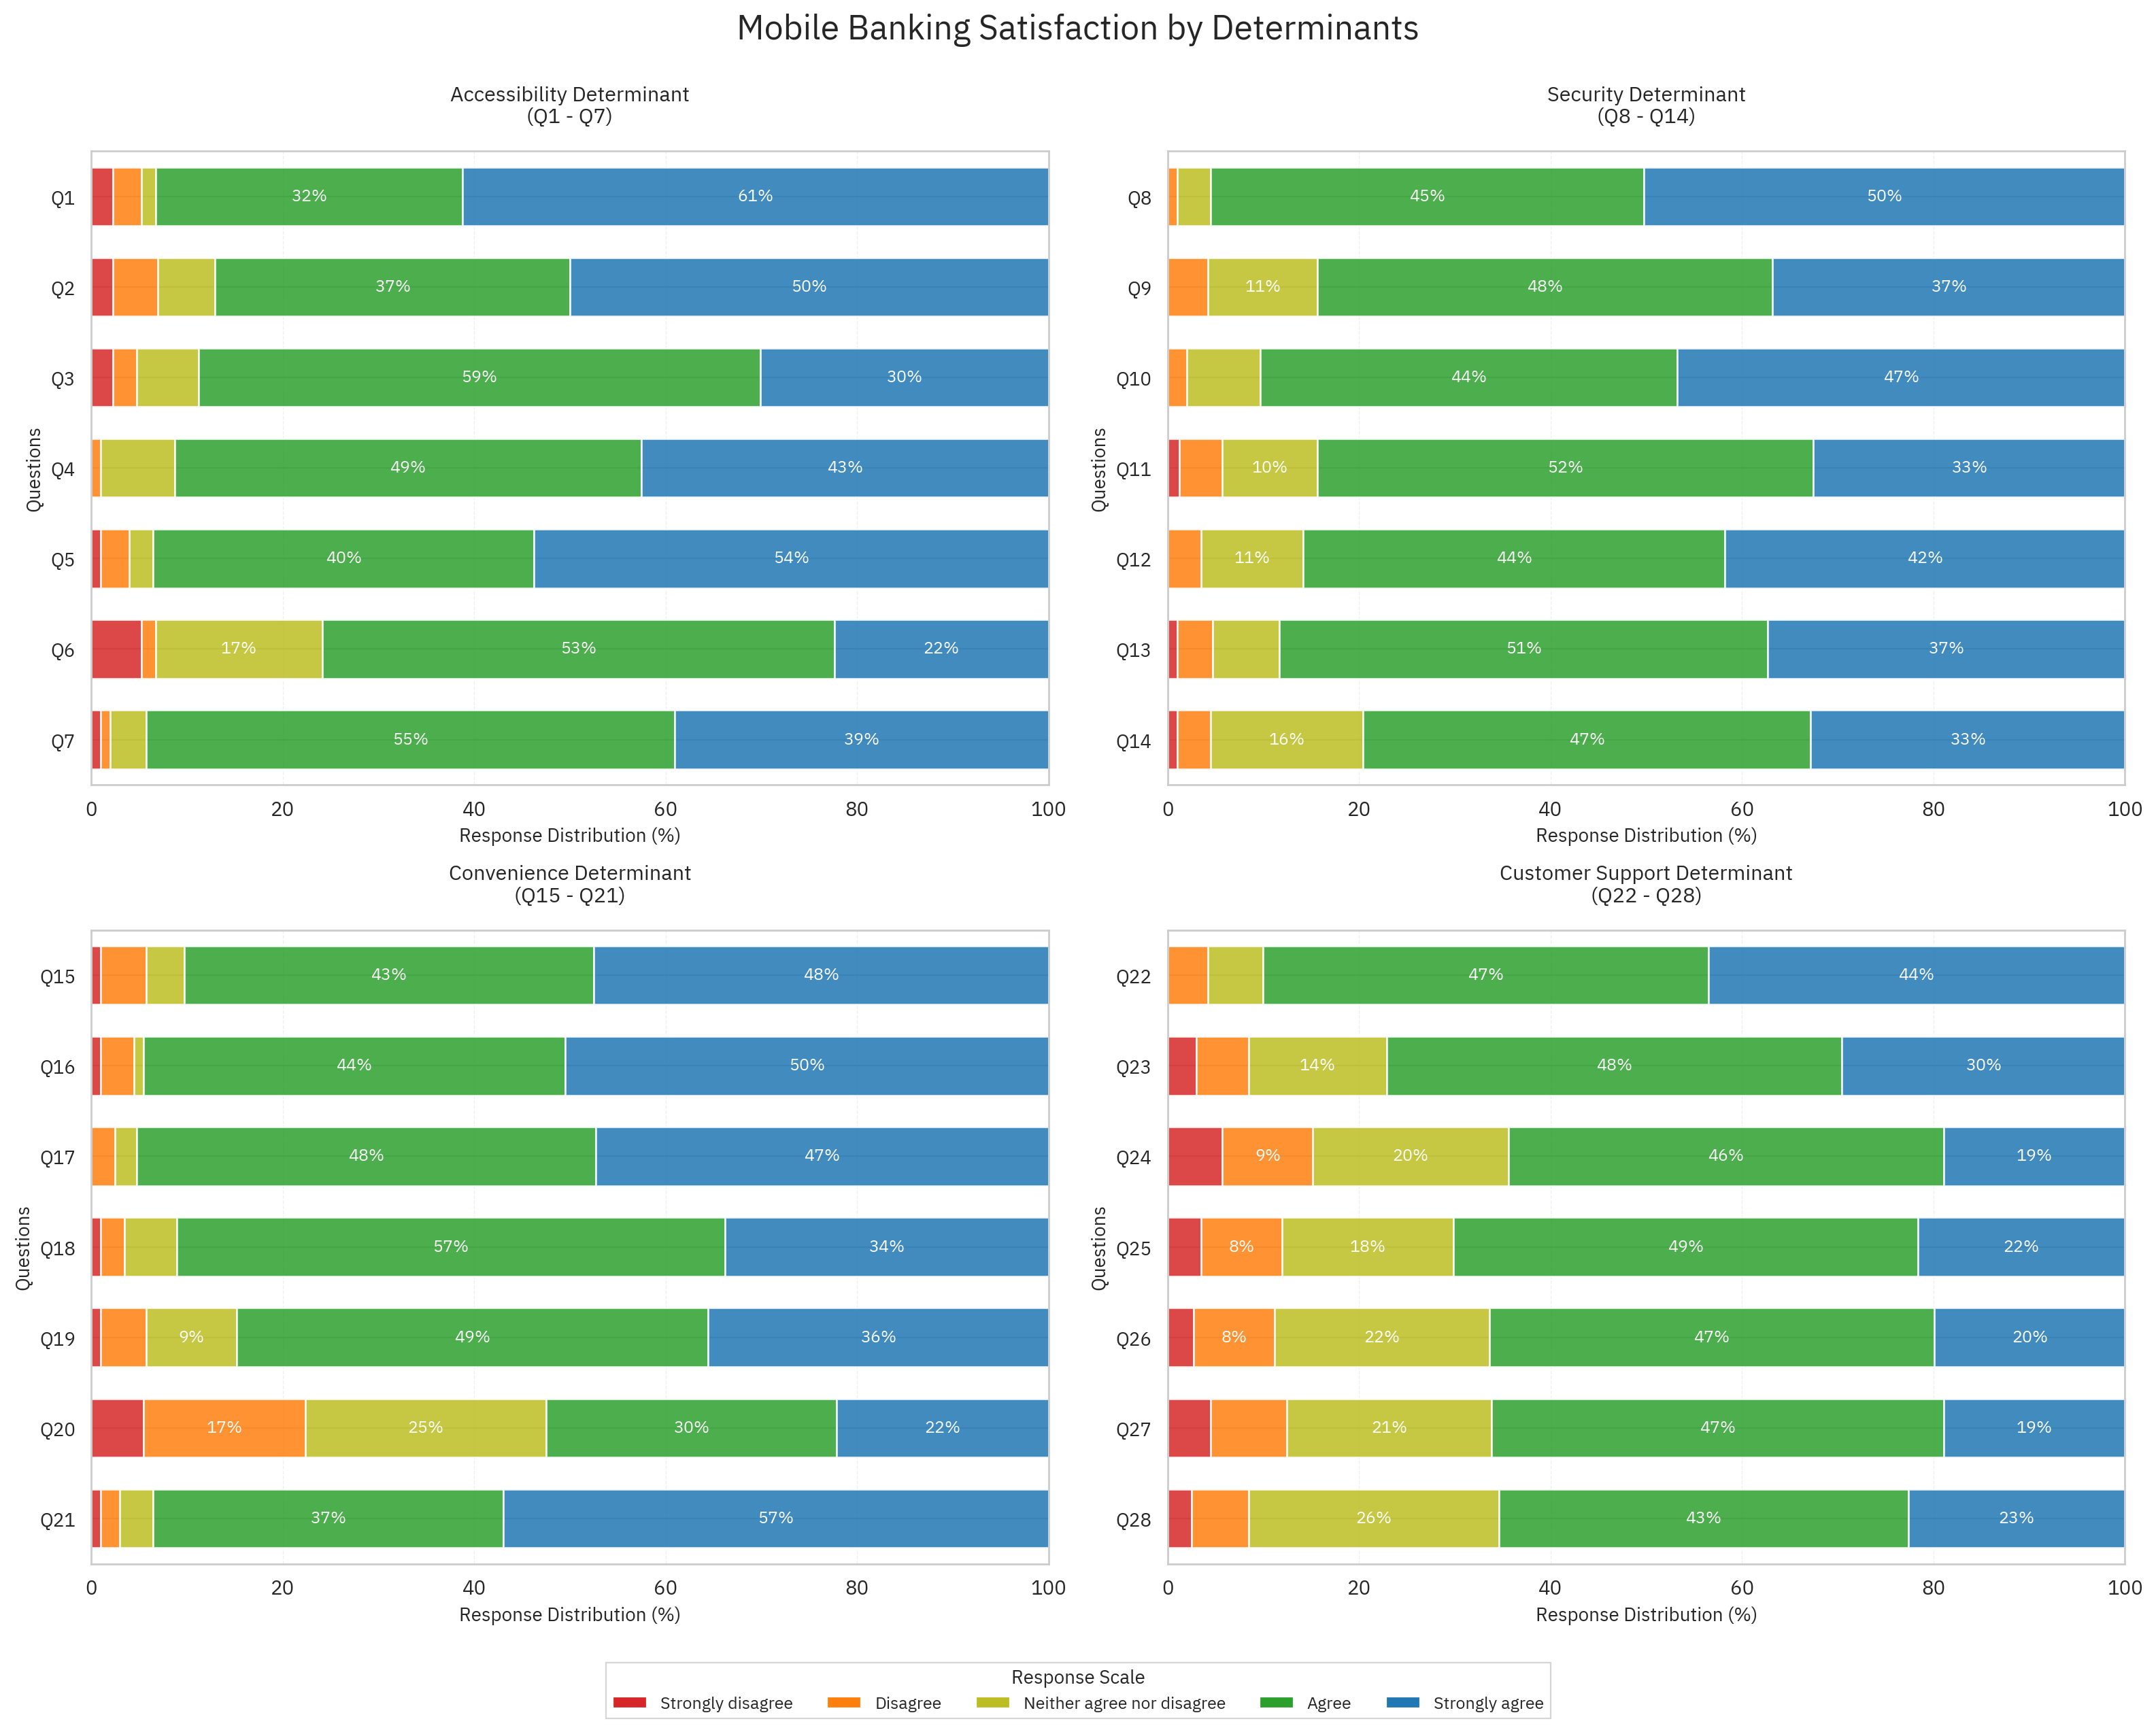


🎨 SEABORN PAPER STYLE APPLIED:
   ✅ Paper context with appropriate sizing
   ✅ White grid background
   ✅ IBM Plex Sans font maintained
   ✅ Publication-ready appearance
   ✅ Horizontal legend at bottom


In [15]:
# UPDATED DETERMINANT-BASED STACKED BAR CHARTS - SEABORN PAPER STYLE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set seaborn paper context with IBM Plex Sans font
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'IBM Plex Sans'

determinant_questions = {
    'Accessibility': {
        'Q1': "​​The mobile banking app allows me to easily access and manage my​ account at any time. ",
        'Q2': "​​The mobile banking app works efficiently across multiple devices (e.g., smartphone,​ ​tablet).​ ",
        'Q3': "​​The loading speed of the mobile banking app is fast and reliable.​",
        'Q4': "​​The mobile banking app’s interface is user-friendly and intuitive to navigate​. ",
        'Q5': "​​I can easily access essential services, such as transfers and bill payments, within the​ app. ",
        'Q6': "​​The app has minimal errors and disruptions when I perform banking tasks.​ ",
        'Q7': "​​The design of the mobile banking app allows me to complete tasks efficiently.​ "
    },
    'Security': {
        'Q8': "​​The mobile banking app ensures secure login and authentication for each session.​",
        'Q9': "​​I feel confident that my personal information is protected by the app’s strong encryption​ methods.",
        'Q10': "​​The app provides advanced security features, such as two-factor authentication (2FA).​",
        'Q11': "​​I trust the app’s security features and monitoring systems to safeguard my financial​ information.",
        'Q12': "​​The app actively monitors for suspicious activity and prevents unauthorized access.​ ",
        'Q13': "​​I can easily adjust and control the​ ​app's security settings to suit my preferences​.",
        'Q14': "​​The app’s fraud detection mechanisms make me feel secure while conducting​ transactions."
    },
    'Convenience': {
        'Q15': "​​The mobile banking app allows me to perform transactions efficiently and in a timely​ manner. ",
        'Q16': "​​I can access the mobile banking app anytime, day or night.​ ",
        'Q17': "​​I can easily integrate the app with other financial services such as bill payments and​ transfers.",
        'Q18': "​​The app offers personalized features that enhance my banking experience beyond​ ​basic tasks.​",
        'Q19': "​​I receive useful updates and notifications regarding my account.​ ",
        'Q20': "​​I can use the mobile banking app reliably even in areas with slow internet connectivity.​",
        'Q21': "​​The app’s features save me time compared to in-person banking services.​"
    },
    'Customer Support': {
        'Q22': "​​The mobile banking app provides prompt notifications regarding my transactions.​",
        'Q23': "​​The app offers multiple support channels (e.g., chat, email, phone) to resolve issues.​",
        'Q24': "​​Customer support through the app responds promptly and​ resolves concerns effectively.",
        'Q25': "​​I find the support staff to be knowledgeable and helpful in resolving issues.​ ",
        'Q26': "​​The mobile banking app provides timely responses to my queries and concerns.​ ",
        'Q27': "​​I feel supported by the app’s customer service when I experience issues.​ ",
        'Q28': "​​The app allows me to easily track the status of my support requests.​ "
    }
}

print("🎯 CREATING DETERMINANT-BASED STACKED BAR CHARTS (SEABORN PAPER STYLE)")
print("=" * 70)

# Define consistent colors for Likert scale responses
response_colors = {
    'Strongly Disagree': '#d62728',
    'Disagree': '#ff7f0e', 
    'Neutral': '#bcbd22',
    'Neither agree nor disagree': '#bcbd22',
    'Agree': '#2ca02c',
    'Strongly Agree': '#1f77b4',
    'Strongly agree': '#1f77b4',
    '1 - Strongly disagree': '#d62728',
    '2 - Disagree': '#ff7f0e',
    '3 - Neither disagree nor agree': '#bcbd22',
    '3 - Neither agree nor disagree': '#bcbd22',
    '4 - Agree': '#2ca02c',
    '5 - Strongly agree': '#1f77b4'
}

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (determinant, questions) in enumerate(determinant_questions.items()):
    ax = axes[i]
    
    # Prepare data for this determinant
    y_positions = []
    y_labels = []
    all_responses = set()
    
    # Count valid questions
    valid_questions = []
    
    # Collect all possible responses
    for q_label, question_text in questions.items():
        if question_text in df_copy.columns:
            valid_questions.append((q_label, question_text))
            responses = df_copy[question_text].dropna().unique()
            all_responses.update(responses)
    
    # Order responses logically
    response_order = ['1 - Strongly disagree', '2 - Disagree', '3 - Neither disagree nor agree',
                     '3 - Neither agree nor disagree', '4 - Agree', '5 - Strongly agree',
                     'Strongly Disagree', 'Disagree', 'Neutral', 'Neither agree nor disagree', 
                     'Agree', 'Strongly Agree', 'Strongly agree']
    
    ordered_responses = []
    for response in response_order:
        if response in all_responses:
            ordered_responses.append(response)
    
    # Add any remaining responses
    for response in all_responses:
        if response not in ordered_responses:
            ordered_responses.append(response)
    
    # Create stacked bars
    for j, (q_label, question_text) in enumerate(valid_questions):
        value_counts = df_copy[question_text].value_counts()
        percentages = (value_counts / value_counts.sum()) * 100
        
        y_positions.append(j)
        y_labels.append(q_label)
        
        left = 0
        for response in ordered_responses:
            if response in percentages.index:
                percentage = percentages[response]
                color = response_colors.get(response, '#7f7f7f')
                
                ax.barh(j, percentage, left=left, color=color, 
                       alpha=0.85, height=0.65, edgecolor='white', linewidth=1)
                
                if percentage > 8:
                    ax.text(left + percentage/2, j, f'{percentage:.0f}%', 
                           ha='center', va='center', fontweight='bold', 
                           fontsize=9, color='white')
                
                left += percentage
    
    # Customize the subplot
    ax.set_xlim(0, 100)
    ax.set_ylim(-0.5, len(y_positions) - 0.5)
    ax.set_xlabel('Response Distribution (%)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Questions', fontsize=10, fontweight='bold')
    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontsize=10, fontweight='bold')
    
    if valid_questions:
        first_q = valid_questions[0][0]
        last_q = valid_questions[-1][0]
        ax.set_title(f'{determinant} Determinant\n({first_q} - {last_q})', 
                    fontsize=11, fontweight='bold', pad=15)
    else:
        ax.set_title(f'{determinant} Determinant\n(No Valid Questions Found)', 
                    fontsize=11, fontweight='bold', pad=15)
    
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.invert_yaxis()
    
    print(f"✅ {determinant}: {len(valid_questions)} valid questions plotted")

# Create unified legend at the bottom horizontally
if ordered_responses:
    legend_elements = []
    legend_labels = []
    for response in ordered_responses:
        color = response_colors.get(response, '#7f7f7f')
        legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=color))
        clean_label = response.replace('1 - ', '').replace('2 - ', '').replace('3 - ', '').replace('4 - ', '').replace('5 - ', '')
        legend_labels.append(clean_label)

    fig.legend(legend_elements, legend_labels, 
              loc='lower center', bbox_to_anchor=(0.5, -0.02),
              fontsize=9, title='Response Scale', title_fontsize=10,
              frameon=True, fancybox=False, shadow=False,
              ncol=len(legend_labels))

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
fig.suptitle('Mobile Banking Satisfaction by Determinants', 
             fontsize=18, fontweight='bold', y=1.03)

plt.show()

print(f"\n🎨 SEABORN PAPER STYLE APPLIED:")
print("   ✅ Paper context with appropriate sizing")
print("   ✅ White grid background")
print("   ✅ IBM Plex Sans font maintained")
print("   ✅ Publication-ready appearance")
print("   ✅ Horizontal legend at bottom")


## MCDA

In [16]:
survey_df_copy = df_copy.copy()

In [17]:
rating_map = {
    '1 - Strongly disagree': 1,
    '2 - Disagree': 2,
    '3 - Neither agree nor disagree': 3,
    '4 - Agree': 4,
    '5 - Strongly agree': 5
}

for col in survey_df_copy.columns:
    # List of non-rating columns to exclude
    if col not in ['Timestamp', 'Column 1', 'Age', 'Gender', 'Educational attainment',
                   'Employment', 'Income level (monthly)', 'Do you have a bank account?',
                   '​​Does your bank offer facilities on mobile banking?​ ',
                   'Do you use mobile banking?', 'Frequency of using mobile banking', 'How long have you been using mobile banking services?',
       'Which bank do you use most frequently for mobile banking transactions?']:
        survey_df_copy[col] = survey_df_copy[col].map(rating_map)

In [18]:
df_review = pd.read_csv('/Users/mochi/Projects/thesis-bank-sats/data/output_data/english/version_2/classified_reviews_comprehensive.csv')


In [19]:
df_review

,processed_review,topic_classification,classification_status,score,bank
0,fix your app.. so long na hindi ako nakakapag ...,"{\n ""topics"": [""Convenience""],\n ""ratings"": ...",completed,1,BDO
1,Can't use bank transfer for 2 weeks already. P...,"{\n ""topics"": [""Convenience"", ""Customer Suppo...",completed,2,BDO
2,won't let me send money for some reason even t...,"{\n ""topics"": [""Convenience"", ""Security""],\n ...",completed,3,BDO
3,worst app ever created. cannot transfer money ...,"{\n ""topics"": [""Convenience""],\n ""ratings"": ...",completed,1,BDO
4,Did you remove your Globe/TM as your Telecom p...,"{\n ""topics"": [""Accessibility""],\n ""ratings""...",completed,2,BDO
...,...,...,...,...,...
42734,My bad. Everything is a OK now. That review on...,"{\n ""topics"": [],\n ""ratings"": {}\n}",completed,5,Unionbank
42735,App is under maintenance. No notice when the h...,"{\n ""topics"": [""Accessibility"", ""Customer Sup...",completed,1,Unionbank
42736,I am loving UB before because it's convenient ...,"{\n ""topics"": [""Convenience"", ""Security""],\n ...",completed,1,Unionbank
42737,Di ko na magamit online banking ko dahil nawal...,"{\n ""topics"": [""Accessibility"", ""Security""],\...",completed,4,Unionbank


In [20]:
import json
import re

def clean_and_parse_topic_classification(text):
    """
    Clean and parse topic classification text into structured format
    """
    if pd.isna(text) or text is None:
        return None, None
    
    # Convert to string and clean
    text = str(text).strip()
    
    # Remove markdown code block formatting if present
    text = re.sub(r'^```json\s*', '', text)
    text = re.sub(r'\s*```$', '', text)
    
    # Try to parse as JSON
    try:
        parsed = json.loads(text)
        
        # Handle case where parsed is a list instead of dict
        if isinstance(parsed, list):
            return None, None
        
        # Handle case where parsed is a dict
        if isinstance(parsed, dict):
            topics = parsed.get('topics', [])
            ratings = parsed.get('ratings', {})
            return topics, ratings
        
        # Unexpected type
        return None, None
        
    except json.JSONDecodeError:
        # If JSON parsing fails, try to extract topics manually
        try:
            # Look for patterns like "topics": ["topic1", "topic2"]
            topics_match = re.search(r'"topics":\s*\[(.*?)\]', text)
            if topics_match:
                topics_str = topics_match.group(1)
                topics = [t.strip().strip('"') for t in topics_str.split(',') if t.strip()]
                return topics, {}
            else:
                return None, None
        except:
            return None, None

# Test the function on a few samples
print("🧪 Testing parsing function:")
test_samples = df_review['topic_classification'].dropna().head(5)
for i, sample in enumerate(test_samples):
    topics, ratings = clean_and_parse_topic_classification(sample)
    print(f"{i+1}: Topics: {topics}, Ratings: {ratings}")

🧪 Testing parsing function:
1: Topics: ['Convenience'], Ratings: {'Convenience': 1}
2: Topics: ['Convenience', 'Customer Support'], Ratings: {'Convenience': 1, 'Customer Support': 1}
3: Topics: ['Convenience', 'Security'], Ratings: {'Convenience': 1, 'Security': 3}
4: Topics: ['Convenience'], Ratings: {'Convenience': 1}
5: Topics: ['Accessibility'], Ratings: {'Accessibility': 1}


In [21]:
def preprocess_topic_classifications(df):
    """
    Preprocess topic classifications into separate columns for ML
    
    Creates:
    - Binary columns for each topic (1 if present, 0 if not)
    - Rating columns for each topic (actual rating if present, NaN if not)
    - Missing indicator columns (1 if missing, 0 if present)
    """
    
    print("🔄 Preprocessing topic classifications...")
    
    # Define the expected topics
    topics = ['Accessibility', 'Security', 'Convenience', 'Customer Support']
    
    # Create a copy of the dataframe
    df_processed = df.copy()
    
    # Initialize columns with proper dtypes
    for topic in topics:
        topic_clean = topic.lower().replace(' ', '_')
        # df_processed[f'{topic_clean}_present'] = 0  # Binary: topic present
        df_processed[f'{topic_clean}_rating'] = np.nan  # Rating if present
        # df_processed[f'{topic_clean}_missing'] = 1  # Missing indicator
    
    # Convert rating columns to float
    for topic in topics:
        topic_clean = topic.lower().replace(' ', '_')
        df_processed[f'{topic_clean}_rating'] = df_processed[f'{topic_clean}_rating'].astype('float64')
    
    # Parse each classification
    parsing_errors = 0
    successful_parses = 0
    
    for idx, row in df_processed.iterrows():
        classification_text = row['topic_classification']
        
        # Parse the classification
        parsed_topics, parsed_ratings = clean_and_parse_topic_classification(classification_text)
        
        if parsed_topics is not None:
            successful_parses += 1
            
            # Reset all topics to not present for this row
            for topic in topics:
                topic_clean = topic.lower().replace(' ', '_')
                # df_processed.loc[idx, f'{topic_clean}_present'] = 0
                df_processed.loc[idx, f'{topic_clean}_rating'] = np.nan
                # df_processed.loc[idx, f'{topic_clean}_missing'] = 1
            
            # Set present topics
            for topic in parsed_topics:
                if topic in topics:
                    topic_clean = topic.lower().replace(' ', '_')
                    df_processed.loc[idx, f'{topic_clean}_present'] = 1
                    df_processed.loc[idx, f'{topic_clean}_missing'] = 0
                    
                    # Set rating if available - ensure it's numeric
                    if parsed_ratings and topic in parsed_ratings:
                        try:
                            rating_value = float(parsed_ratings[topic])
                            df_processed.loc[idx, f'{topic_clean}_rating'] = rating_value
                        except (ValueError, TypeError):
                            # If rating can't be converted to float, skip it
                            pass
        else:
            parsing_errors += 1
    
    print(f"✅ Preprocessing completed:")
    print(f"   Successfully parsed: {successful_parses:,}")
    print(f"   Parsing errors: {parsing_errors:,}")
    print(f"   Total rows: {len(df_processed):,}")
    
    # Show summary statistics
    print(f"\n📊 Topic Presence Summary:")
    for topic in topics:
        topic_clean = topic.lower().replace(' ', '_')
        present_count = df_processed[f'{topic_clean}_present'].sum()
        present_pct = (present_count / len(df_processed)) * 100
        print(f"   {topic}: {present_count:,} ({present_pct:.1f}%)")
    
    # Show rating statistics
    print(f"\n⭐ Rating Statistics:")
    for topic in topics:
        topic_clean = topic.lower().replace(' ', '_')
        ratings = df_processed[f'{topic_clean}_rating'].dropna()
        if len(ratings) > 0:
            print(f"   {topic}: avg={ratings.mean():.2f}, count={len(ratings):,}, range={ratings.min()}-{ratings.max()}")
        else:
            print(f"   {topic}: No ratings available")
    
    return df_processed

# Apply preprocessing
df_with_topics = preprocess_topic_classifications(df_review)

🔄 Preprocessing topic classifications...
✅ Preprocessing completed:
   Successfully parsed: 42,739
   Parsing errors: 0
   Total rows: 42,739

📊 Topic Presence Summary:
   Accessibility: 8,629.0 (20.2%)
   Security: 15,676.0 (36.7%)
   Convenience: 35,698.0 (83.5%)
   Customer Support: 13,059.0 (30.6%)

⭐ Rating Statistics:
   Accessibility: avg=1.22, count=8,629, range=1.0-5.0
   Security: avg=1.70, count=15,676, range=1.0-5.0
   Convenience: avg=1.49, count=35,698, range=1.0-5.0
   Customer Support: avg=1.27, count=13,051, range=1.0-5.0


In [22]:
df_with_topics

,processed_review,topic_classification,classification_status,score,bank,accessibility_rating,security_rating,convenience_rating,customer_support_rating,convenience_present,convenience_missing,customer_support_present,customer_support_missing,security_present,security_missing,accessibility_present,accessibility_missing
0,fix your app.. so long na hindi ako nakakapag ...,"{\n ""topics"": [""Convenience""],\n ""ratings"": ...",completed,1,BDO,NaN,NaN,1.0,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Can't use bank transfer for 2 weeks already. P...,"{\n ""topics"": [""Convenience"", ""Customer Suppo...",completed,2,BDO,NaN,NaN,1.0,1.0,1.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN
2,won't let me send money for some reason even t...,"{\n ""topics"": [""Convenience"", ""Security""],\n ...",completed,3,BDO,NaN,3.0,1.0,NaN,1.0,0.0,NaN,NaN,1.0,0.0,NaN,NaN
3,worst app ever created. cannot transfer money ...,"{\n ""topics"": [""Convenience""],\n ""ratings"": ...",completed,1,BDO,NaN,NaN,1.0,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,Did you remove your Globe/TM as your Telecom p...,"{\n ""topics"": [""Accessibility""],\n ""ratings""...",completed,2,BDO,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42734,My bad. Everything is a OK now. That review on...,"{\n ""topics"": [],\n ""ratings"": {}\n}",completed,5,Unionbank,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42735,App is under maintenance. No notice when the h...,"{\n ""topics"": [""Accessibility"", ""Customer Sup...",completed,1,Unionbank,1.0,NaN,NaN,1.0,NaN,NaN,1.0,0.0,NaN,NaN,1.0,0.0
42736,I am loving UB before because it's convenient ...,"{\n ""topics"": [""Convenience"", ""Security""],\n ...",completed,1,Unionbank,NaN,1.0,1.0,NaN,1.0,0.0,NaN,NaN,1.0,0.0,NaN,NaN
42737,Di ko na magamit online banking ko dahil nawal...,"{\n ""topics"": [""Accessibility"", ""Security""],\...",completed,4,Unionbank,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0,0.0


In [23]:
# Remove leading/trailing whitespace and hidden unicode from column names
survey_df_copy.columns = survey_df_copy.columns.str.strip().str.replace('\u200b', '').str.replace('\u200c', '')
print((survey_df_copy.columns))

# Define determinant groups for survey data (already numeric)
determinant_groups = {
   'accessibility': [
      'The mobile banking app allows me to easily access and manage my account at any time.',
      'The mobile banking app works efficiently across multiple devices (e.g., smartphone, tablet).',
      'The loading speed of the mobile banking app is fast and reliable.',
      'The mobile banking app’s interface is user-friendly and intuitive to navigate.',
      'I can easily access essential services, such as transfers and bill payments, within the app.',
      'The app has minimal errors and disruptions when I perform banking tasks.',
      'The design of the mobile banking app allows me to complete tasks efficiently.'
   ],
   'security': [
      'The mobile banking app ensures secure login and authentication for each session.',
      'I feel confident that my personal information is protected by the app’s strong encryption methods.',
      'The app provides advanced security features, such as two-factor authentication (2FA).',
      'I trust the app’s security features and monitoring systems to safeguard my financial information.',
      'The app actively monitors for suspicious activity and prevents unauthorized access.',
      "I can easily adjust and control the app's security settings to suit my preferences.",
      'The app’s fraud detection mechanisms make me feel secure while conducting transactions.'
   ],
   'convenience': [
      'The mobile banking app allows me to perform transactions efficiently and in a timely manner.',
      'I can access the mobile banking app anytime, day or night.',
      'I can easily integrate the app with other financial services such as bill payments and transfers.',
      'The app offers personalized features that enhance my banking experience beyond basic tasks.',
      'I receive useful updates and notifications regarding my account.',
      'I can use the mobile banking app reliably even in areas with slow internet connectivity.',
      'The app’s features save me time compared to in-person banking services.'
   ],
   'customer_support': [
      'The mobile banking app provides prompt notifications regarding my transactions.',
      'The app offers multiple support channels (e.g., chat, email, phone) to resolve issues.',
      'Customer support through the app responds promptly and resolves concerns effectively.',
      'I find the support staff to be knowledgeable and helpful in resolving issues.',
      'The mobile banking app provides timely responses to my queries and concerns.',
      'I feel supported by the app’s customer service when I experience issues.',
      'The app allows me to easily track the status of my support requests.'
   ],
}

# For review data, use *_rating columns from df_with_topics
review_det_columns = {
   'accessibility': ['accessibility_rating'],
   'security': ['security_rating'],
   'convenience': ['convenience_rating'],
   'customer_support': ['customer_support_rating']
}

mcda_weights = {}

# Calculate mean/aggregate score for each determinant for each respondent (survey)
for det, columns in determinant_groups.items():
   survey_df_copy[f'{det}_score'] = survey_df_copy[columns].mean(axis=1)

# Calculate mean/aggregate score for each determinant for each review (reviews)
for det, columns in review_det_columns.items():
   df_with_topics[f'{det}_score'] = df_with_topics[columns].mean(axis=1)

# Combine both sources for MCDA weights calculation
all_scores = {}
for det in determinant_groups:
   # Survey mean
   survey_mean = survey_df_copy[f'{det}_score'].mean()
   # Review mean (ignore NaN)
   review_mean = df_with_topics[f'{det}_score'].mean()
   # Weighted average (equal weight for survey and review, adjust as needed)
   all_scores[det] = (survey_mean + review_mean) / 2

# Normalize to get MCDA weights
total = sum(all_scores.values())
for det in all_scores:
   mcda_weights[det] = all_scores[det] / total

print("Integrated MCDA/AHP Weights (Survey + Reviews):", mcda_weights)

Index(['Timestamp', 'Column 1', 'Age', 'Gender', 'Educational attainment',
       'Employment', 'Income level (monthly)', 'Do you have a bank account?',
       'Does your bank offer facilities on mobile banking?',
       'Do you use mobile banking?', 'Frequency of using mobile banking',
       'How long have you been using mobile banking services?',
       'Which bank do you use most frequently for mobile banking transactions?',
       'The mobile banking app allows me to easily access and manage my account at any time.',
       'The mobile banking app works efficiently across multiple devices (e.g., smartphone, tablet).',
       'The loading speed of the mobile banking app is fast and reliable.',
       'The mobile banking app’s interface is user-friendly and intuitive to navigate.',
       'I can easily access essential services, such as transfers and bill payments, within the app.',
       'The app has minimal errors and disruptions when I perform banking tasks.',
       'The design

In [24]:
print(pd.DataFrame.from_dict(mcda_weights, orient='index', columns=['Weight']))

                    Weight
accessibility     0.247010
security          0.267166
convenience       0.256102
customer_support  0.229722


In [27]:
# Reliability analysis (Cronbach's alpha) for each determinant
def cronbach_alpha(df):
    df = df.dropna(axis=1, how='all')  # Drop columns with all NaNs
    item_vars = df.var(axis=0, ddof=1)
    total_var = df.sum(axis=1).var(ddof=1)
    n_items = df.shape[1]
    if n_items <= 1:
        return np.nan  # Cronbach's alpha is not defined for 1 or fewer items
    alpha = (n_items / (n_items - 1)) * (1 - item_vars.sum() / total_var)
    return alpha

reliability_results = {}
for det, columns in determinant_groups.items():
    alpha = cronbach_alpha(survey_df_copy[columns])
    reliability_results[det] = alpha

In [28]:
# Cronbach's alpha results
print("Reliability Analysis (Cronbach's Alpha):")
for det, alpha in reliability_results.items():
    print(f" - {det}: {alpha:.3f}")

Reliability Analysis (Cronbach's Alpha):
 - accessibility: 0.891
 - security: 0.920
 - convenience: 0.888
 - customer_support: 0.934


In [29]:
def cronbach_alpha(df):
    df = df.dropna(axis=1, how='all') # Drop columns with all NaNs
    if df.shape[1] <= 1:
        return np.nan # Not defined for 1 or fewer items
    item_vars = df.var(axis=0, ddof=1)
    # Ensure total_var is calculated correctly and handles potential division by zero
    total_var = df.sum(axis=1).var(ddof=1)
    if total_var == 0:
         return np.nan # If total variance is zero, alpha is undefined or 1
    n_items = df.shape[1]
    alpha = (n_items / (n_items - 1)) * (1 - item_vars.sum() / total_var)
    return alpha

# --- Calculate Overall Alpha ---

# 1. Combine all item columns into a single list
all_item_columns = []
for columns in determinant_groups.values():
    all_item_columns.extend(columns)

# 2. Create a DataFrame with only these item columns
overall_items_df = survey_df_copy[all_item_columns]

# 3. Calculate the overall Cronbach's alpha
overall_alpha = cronbach_alpha(overall_items_df)

# --- Print the results ---
print("--- Reliability Analysis ---")
for det, alpha in reliability_results.items():
    print(f"🔹 Cronbach's Alpha for '{det}': {alpha:.4f}")

print(f"\n✨ Overall Cronbach's Alpha for all items: {overall_alpha:.4f}")

# --- Interpretation Guide ---
print("\n--- Interpretation Guide ---")
print(" > 0.9: Excellent")
print("0.8-0.9: Good")
print("0.7-0.8: Acceptable")
print("0.6-0.7: Questionable")
print("0.5-0.6: Poor")
print(" < 0.5: Unacceptable")

--- Reliability Analysis ---
🔹 Cronbach's Alpha for 'accessibility': 0.8911
🔹 Cronbach's Alpha for 'security': 0.9202
🔹 Cronbach's Alpha for 'convenience': 0.8875
🔹 Cronbach's Alpha for 'customer_support': 0.9344

✨ Overall Cronbach's Alpha for all items: 0.9611

--- Interpretation Guide ---
 > 0.9: Excellent
0.8-0.9: Good
0.7-0.8: Acceptable
0.6-0.7: Questionable
0.5-0.6: Poor
 < 0.5: Unacceptable
